# B16 — Measurement with SamplerV2

**Track B — the SDK.** A04 built the Born rule as an actual sampler: cumulative
distribution, one uniform draw per shot, `np.searchsorted`. Eleven lines, nothing
hidden. This notebook hands that job to Qiskit — and then does the thing almost
no tutorial does, which is to *look at what comes back before it is averaged*.

---

## The one-sentence version

A quantum computer does not return a probability. It returns a **stack of
bitstrings** — one row per shot, one column per measured qubit — and every
probability you have ever seen plotted was computed from such a stack by
throwing the row order away.

That stack is the real output. `get_counts()` is a lossy summary of it. So the
centrepiece of this notebook is a picture of the stack itself: a bitmap, one
pixel per measured bit. It is the actual randomness, at full resolution.

| Track A (A04, by hand) | Qiskit 2.x |
|---|---|
| `measure_shots(psi, N, rng)` | `sampler.run([pub], shots=N)` |
| `rng.random(shots)` + inverse CDF | the primitive's internal RNG, seeded |
| an array of outcome indices | a `BitArray` |
| `np.bincount(outcomes)` | `result[0].data.c.get_counts()` |
| the indices themselves | `result[0].data.c.get_bitstrings()` / `.array` |
| `1/\sqrt{N}` shot noise | exactly the same `1/\sqrt{N}` shot noise |

The last row is the point of doing it twice. The SDK changes the ergonomics and
changes nothing at all about the statistics.

## A warning that will save you an afternoon

Two APIs in this area are dead on the pinned Qiskit 2.5.1:

```python
from qiskit.primitives import Sampler      # Primitives V1 - removed in 2.0
from qiskit import execute                 # removed in 1.0
counts = execute(qc, backend, shots=1024).result().get_counts()
```

Nearly every measurement tutorial online is written against those three lines.
The V2 replacements — and the one sharp edge in them, the classical register's
*name* — are the first two sections below.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.circuit.library import StatePreparation
from qiskit.primitives import StatevectorSampler
from qiskit.primitives.containers import BitArray
from qiskit.quantum_info import Statevector
from matplotlib.colors import ListedColormap

style.use()

SEED = backends.seed_for("B16")
rng = np.random.default_rng(SEED)          # the Track A side, for the checkpoint
print("qiskit", qiskit.__version__, " seed", SEED)

qiskit 2.5.1  seed 20260820


---

## Part 1 — the PUB, and the two samplers

### What a PUB is

V2 primitives take a list of **PUBs** — *primitive unified blocs*. A sampler PUB
is a tuple

```python
(circuit, parameter_values, shots)
```

with the last two optional, and a bare circuit is accepted as shorthand for
`(circuit,)`. The list is the batch: one PUB in, one result out, addressed as
`result[0]`, `result[1]`, and so on.

The reason for the format is that the *parameter values* slot is an array. One
PUB can carry a whole sweep of parameter bindings, which the backend runs as one
job. That is why `result[0].data.c` can come back with a shape — we use it at
the end of this part.

### Two samplers, and when to use which

| | `StatevectorSampler` | Aer's `SamplerV2` |
|---|---|---|
| lives in | `qiskit.primitives` (the SDK itself) | `qiskit_aer.primitives` |
| how it works | builds the exact `2^n` statevector, then draws from it | a real shot-by-shot simulation |
| noise models | no | yes |
| scaling | dies at ~25 qubits | dies later, and stabilizer circuits scale much further |
| seeding | `StatevectorSampler(seed=...)` | `SamplerV2(seed=...)` |
| use it for | small, exact, reference results | anything with noise, or many shots |

Both are V2 and both take a `seed`. That symmetry does **not** extend to the
estimators: Aer's `EstimatorV2` takes no `seed` argument at all and must be fed
`options={"backend_options": {"seed_simulator": N}}`. Every notebook in this
repo goes through `qviz.backends.sampler()` / `.estimator()` so that asymmetry
is handled in one place instead of thirty.

In [2]:
# The state from A04: four deliberately uneven probabilities, with phases
# scattered around so we can watch measurement ignore them completely.
TARGET_P = np.array([0.45, 0.05, 0.20, 0.30])
PHASES = np.array([0.0, np.pi / 2, np.pi, -np.pi / 4])
PSI = np.sqrt(TARGET_P) * np.exp(1j * PHASES)
LABELS = ["00", "01", "10", "11"]

# The repo convention: an EXPLICIT ClassicalRegister named "c". See Part 2.
qr, cr = QuantumRegister(2, "q"), ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr)
qc.append(StatePreparation(PSI), qr)       # prepare |psi> exactly
qc.measure(qr, cr)

# Aer cannot execute a `state_preparation` instruction directly - it is not in
# the simulator's basis. Transpiling is not optional here, and it is seeded:
# `transpile` makes stochastic choices at higher optimization levels.
AER = backends.get_backend()
qc_isa = transpile(qc, AER, optimization_level=1, seed_transpiler=SEED)
print("as written :", dict(qc.count_ops()))
print("as run     :", dict(qc_isa.count_ops()), " depth", qc_isa.depth())

SHOTS = 4096
sv_sampler = StatevectorSampler(seed=SEED)          # SDK, exact
aer_sampler = backends.sampler(shots=SHOTS, seed=SEED)   # Aer, shot-by-shot

res_sv = sv_sampler.run([qc], shots=SHOTS).result()      # bare circuit = a PUB
res_aer = aer_sampler.run([(qc_isa,)]).result()          # explicit 1-tuple PUB

print("\nresult object   :", type(res_aer).__name__, " len", len(res_aer))
print("one PUB result  :", type(res_aer[0]).__name__)
print("its data bin    :", list(res_aer[0].data.keys()), "<- register NAMES")
print("the BitArray    :", type(res_aer[0].data.c).__name__,
      " shots", res_aer[0].data.c.num_shots,
      " bits", res_aer[0].data.c.num_bits)

as written : {'measure': 2, 'state_preparation': 1}
as run     : {'u2': 2, 'measure': 2, 'cx': 1, 'u3': 1}  depth 4



result object   : PrimitiveResult  len 1
one PUB result  : SamplerPubResult
its data bin    : ['c'] <- register NAMES
the BitArray    : BitArray  shots 4096  bits 2


In [3]:
p_exact = np.abs(PSI) ** 2


def freqs(bit_array, dim=4, width=2):
    """Counts dict -> a normalized frequency vector in index order."""
    c = bit_array.get_counts()
    n = sum(c.values())
    return np.array([c.get(format(i, f"0{width}b"), 0) / n for i in range(dim)])


f_sv = freqs(res_sv[0].data.c)
f_aer = freqs(res_aer[0].data.c)

print(f"{'outcome':>8} {'exact':>9} {'Statevector':>12} {'Aer':>9}")
for i, lab in enumerate(LABELS):
    print(f"{lab:>8} {p_exact[i]:9.4f} {f_sv[i]:12.4f} {f_aer[i]:9.4f}")

one_sigma = np.sqrt(p_exact * (1 - p_exact) / SHOTS)
print("\n1-sigma shot noise per outcome:", np.round(one_sigma, 4))
print("StatevectorSampler max deviation:", round(float(np.abs(f_sv - p_exact).max()), 4))
print("Aer SamplerV2     max deviation:", round(float(np.abs(f_aer - p_exact).max()), 4))
print("\nThe two samplers disagree with each other by",
      round(float(np.abs(f_sv - f_aer).max()), 4),
      "- which is shot noise, not a bug. They are independent random draws.")

 outcome     exact  Statevector       Aer
      00    0.4500       0.4492    0.4597
      01    0.0500       0.0476    0.0454
      10    0.2000       0.2085    0.2058
      11    0.3000       0.2947    0.2891

1-sigma shot noise per outcome: [0.0078 0.0034 0.0062 0.0072]
StatevectorSampler max deviation: 0.0085
Aer SamplerV2     max deviation: 0.0109

The two samplers disagree with each other by 0.0105 - which is shot noise, not a bug. They are independent random draws.


---

## Part 2 — the classical-register-name trap

This one costs people real time, so it gets its own section.

A V2 result is not indexed by position. It is indexed by the **name of the
classical register the measurement wrote into**:

```python
result[0].data.<register_name>
```

- `qc.measure_all()` silently creates a register called **`meas`**, so it is
  `result[0].data.meas`.
- `ClassicalRegister(n, "c")` — this repo's convention — gives
  `result[0].data.c`.
- Two registers means two attributes, and each one is a separate `BitArray`.

Getting it wrong is an `AttributeError` at **runtime**, not a wrong number and
not an import error. Which is the good news: it fails loudly. The bad news is
that it fails after the job has run, and on hardware that means after the queue.

Below we do it wrong on purpose.

In [4]:
# (a) measure_all() -> the register is named "meas"
qc_all = QuantumCircuit(2)
qc_all.h(0)
qc_all.cx(0, 1)
qc_all.measure_all()
print("measure_all() created registers:", [c.name for c in qc_all.cregs])

r_all = StatevectorSampler(seed=SEED).run([qc_all], shots=256).result()
print("  data bin keys:", list(r_all[0].data.keys()))
print("  correct access  result[0].data.meas.get_counts() ->",
      r_all[0].data.meas.get_counts())
try:
    r_all[0].data.c
except AttributeError as err:
    print("  wrong access    result[0].data.c            ->  AttributeError:", err)

# (b) two named registers -> two independent BitArrays in one data bin
qra = QuantumRegister(3, "q")
top, bottom = ClassicalRegister(2, "top"), ClassicalRegister(1, "bottom")
qc_two = QuantumCircuit(qra, top, bottom)
qc_two.h(0)
qc_two.cx(0, 1)
qc_two.x(2)
qc_two.measure([0, 1], top)
qc_two.measure([2], bottom)

r_two = StatevectorSampler(seed=SEED).run([qc_two], shots=256).result()
print("\ntwo registers -> data bin keys:", list(r_two[0].data.keys()))
print("  .data.top   :", r_two[0].data.top.get_counts())
print("  .data.bottom:", r_two[0].data.bottom.get_counts())

# The robust idiom when you did not write the circuit yourself: ask the data bin
# instead of guessing. A DataBin is a mapping, so it indexes by string too.
name = list(r_two[0].data.keys())[0]
print("\ngeneric access via the key:", name, "->",
      r_two[0].data[name].get_counts())

measure_all() created registers: ['meas']
  data bin keys: ['meas']
  correct access  result[0].data.meas.get_counts() -> {'00': 125, '11': 131}
  wrong access    result[0].data.c            ->  AttributeError: 'DataBin' object has no attribute 'c'

two registers -> data bin keys: ['top', 'bottom']
  .data.top   : {'00': 125, '11': 131}
  .data.bottom: {'1': 256}

generic access via the key: top -> {'00': 125, '11': 131}


Two smaller traps ride along with that one.

**A `BitArray` is per-register, not per-circuit.** In example (b) there is no
single object holding all three measured bits. If you want them joined you do it
yourself, and you have to decide the bit order when you do.

**Bit order inside a register is Qiskit's, i.e. little-endian.** The bitstring
`"10"` means `c[1] = 1, c[0] = 0`, so the *leftmost* character is the *highest*
clbit. `get_bitstrings()` gives you that string; `to_bool_array()` gives you an
array and lets you choose — `order="little"` puts clbit `j` in **column j**,
which is the layout we want for a bitmap and is what we use below.

---

## Part 3 — the shot record, drawn

Here is the thing this notebook exists for.

A histogram of measurement counts is a *sufficient statistic* for an
independent, identically distributed shot record — but only if you already
believe the shots are independent and identically distributed. That belief is
exactly what the histogram cannot check, because summing over shots is the step
that destroys the evidence.

So draw the record instead. **One row per shot, one column per qubit, one pixel
per measured bit.** Twelve qubits prepared in deliberately different ways, so
that the picture has something to say in every column:

| qubit | prepared as | what the column should look like |
|---|---|---|
| q0 | `H` | a fair coin |
| q1 | nothing | solid — always 0 |
| q2 | `X` | solid — always 1 |
| q3, q4 | Bell pair | two **identical** columns |
| q5, q6 | Bell pair then `X` on q6 | two **complementary** columns |
| q7 | `ry` biased to P(1) = 0.15 | mostly pale |
| q8 | `ry` biased to P(1) = 0.85 | mostly dark |
| q9, q10, q11 | `H` each | three more fair coins, independent |

Nothing in this figure is smoothed, binned or averaged. Every pixel is one bit
that a simulated quantum computer actually returned.

In [5]:
N_Q = 12
N_ROWS = 420          # shots drawn in the bitmap

theta = lambda p1: 2 * np.arcsin(np.sqrt(p1))     # ry angle for a target P(1)

qrec = QuantumRegister(N_Q, "q")
crec = ClassicalRegister(N_Q, "c")
rec = QuantumCircuit(qrec, crec)
rec.h(0)                       # fair coin
                               # q1: left alone -> always 0
rec.x(2)                       # always 1
rec.h(3); rec.cx(3, 4)         # correlated pair
rec.h(5); rec.cx(5, 6); rec.x(6)   # anti-correlated pair
rec.ry(theta(0.15), 7)         # biased low
rec.ry(theta(0.85), 8)         # biased high
for q in (9, 10, 11):
    rec.h(q)                   # three independent fair coins
rec.measure(qrec, crec)

rec_isa = transpile(rec, AER, optimization_level=1, seed_transpiler=SEED)
rec_bits = (backends.sampler(shots=N_ROWS, seed=SEED)
            .run([rec_isa]).result()[0].data.c)

# order="little" -> column j is qubit j. The default is "big", which reverses
# the columns and would silently mirror the whole picture.
BITS = rec_bits.to_bool_array(order="little")
print("BitArray ->", BITS.shape, "(shots, qubits)   dtype", BITS.dtype)
print("first three shots as bitstrings:", rec_bits.get_bitstrings()[:3])
print("the same three rows            :\n", BITS[:3].astype(int))

BitArray -> (420, 12) (shots, qubits)   dtype bool
first three shots as bitstrings: ['000101000101', '011101000100', '001001000100']
the same three rows            :
 [[1 0 1 0 0 0 1 0 1 0 0 0]
 [0 0 1 0 0 0 1 0 1 1 1 0]
 [0 0 1 0 0 0 1 0 0 1 0 0]]


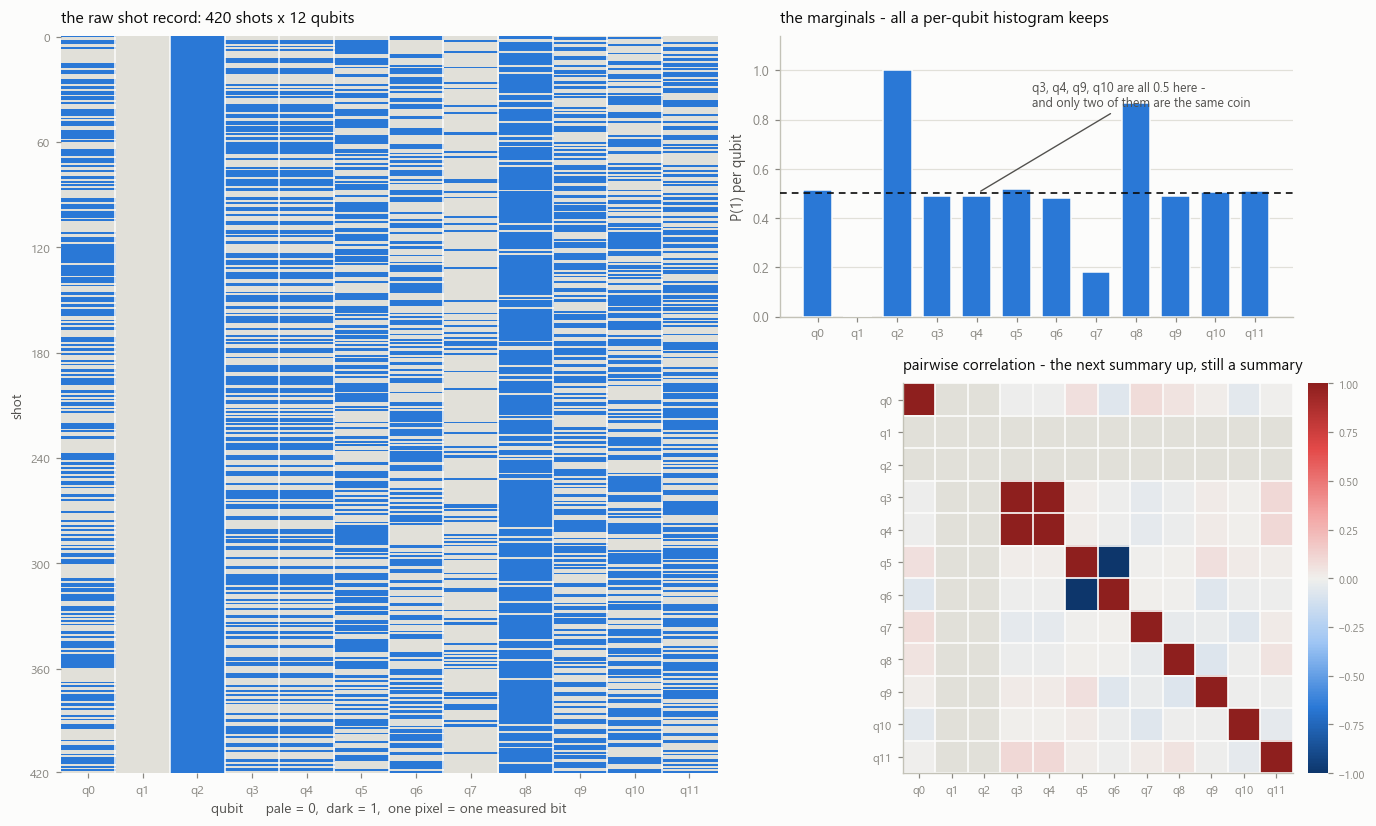

per-qubit P(1): q0=0.514 q1=0.000 q2=1.000 q3=0.490 q4=0.490 q5=0.519 q6=0.481 q7=0.181 q8=0.867 q9=0.490 q10=0.507 q11=0.510

corr(q3, q4)  = 1.0  (Bell pair: identical)
corr(q5, q6)  = -1.0  (Bell pair + X: opposite)
corr(q9, q10) = -0.014  (independent coins)


In [6]:
# --- inline drawing helper -------------------------------------------------
# qviz is the shared drawing layer and is frozen while notebooks are being
# written, so this lives here. It is pure matplotlib: no quantum mechanics.
BIT_CMAP = ListedColormap([style.GRID, style.BLUE])


def shot_bitmap(ax, bits, *, cmap=BIT_CMAP, vmax=1, col_labels=None,
                row_every=60, title=None, ylabel="shot", seps=True):
    """One row per shot, one column per bit. No averaging anywhere."""
    data = np.asarray(bits)
    ax.imshow(data.astype(float), cmap=cmap, vmin=0, vmax=vmax, aspect="auto",
              interpolation="nearest", origin="upper")
    ax.grid(False)
    rows, cols = data.shape
    if seps:
        # Hairlines between columns: without them two adjacent all-dark columns
        # merge into one block and the eye cannot count qubits.
        for x in np.arange(0.5, cols - 0.5):
            ax.axvline(x, color=style.SURFACE, lw=1.0, zorder=4)
    if col_labels is not None:
        ax.set_xticks(range(cols))
        ax.set_xticklabels(col_labels, fontsize=8)
    else:
        ax.set_xticks([])
    ticks = np.arange(0, rows + 1, row_every)
    ax.set_yticks(np.clip(ticks, 0, rows - 1))
    ax.set_yticklabels([str(t) for t in ticks], fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    for sp in ax.spines.values():
        sp.set_visible(False)
    if title:
        ax.set_title(title, loc="left", fontsize=10.5)
    return ax


# --- the figure ------------------------------------------------------------
X = BITS.astype(float)
p1 = X.mean(axis=0)                          # per-qubit P(1), the marginal

# Pairwise correlation of the columns. q1 and q2 are constant, so their standard
# deviation is 0 and their correlation with anything is UNDEFINED - not zero.
# numpy divides by that zero and returns nan; we keep the nan deliberately so
# grid.matrix greys those cells out instead of painting a confident 0.0.
with np.errstate(invalid="ignore", divide="ignore"):
    C = np.corrcoef(X.T)
C[X.std(axis=0) == 0, :] = np.nan
C[:, X.std(axis=0) == 0] = np.nan

fig = plt.figure(figsize=(12.4, 7.4))
gs = fig.add_gridspec(2, 2, width_ratios=[1.28, 1.0], height_ratios=[0.72, 1.0])
axmap = fig.add_subplot(gs[:, 0])
axbar = fig.add_subplot(gs[0, 1])
axcor = fig.add_subplot(gs[1, 1])

QL = [f"q{i}" for i in range(N_Q)]
shot_bitmap(axmap, BITS, col_labels=QL,
            title=f"the raw shot record: {N_ROWS} shots x {N_Q} qubits")
axmap.set_xlabel("qubit      pale = 0,  dark = 1,  one pixel = one measured bit",
                 fontsize=9)

axbar.bar(np.arange(N_Q), p1, width=0.72, color=style.BLUE,
          edgecolor=style.SURFACE, linewidth=1.0, zorder=3)
axbar.axhline(0.5, color=style.INK, lw=1.1, ls=(0, (4, 3)), zorder=4)
axbar.set_xticks(range(N_Q))
axbar.set_xticklabels(QL, fontsize=8)
axbar.set_ylim(0, 1.14)
axbar.set_ylabel("P(1) per qubit")
axbar.set_title("the marginals - all a per-qubit histogram keeps",
                loc="left", fontsize=10.5)
axbar.set_axisbelow(True)
axbar.annotate("q3, q4, q9, q10 are all 0.5 here -\nand only two of them are the same coin",
               xy=(4, 0.5), xytext=(5.4, 0.90), fontsize=8.2,
               color=style.INK_2, ha="left", va="center",
               arrowprops=dict(arrowstyle="-", color=style.INK_2, lw=0.9,
                               shrinkA=2, shrinkB=3))

grid.matrix(axcor, C, part="re", labels=QL, cbar=True, vmax=1.0, annot=False,
            title="pairwise correlation - the next summary up, still a summary")
axcor.tick_params(labelsize=7.5)
# grid.matrix rotates x labels 90 degrees past 8 columns; "q0".."q11" are short
# enough to sit flat, and flat is far easier to read.
axcor.set_xticklabels(QL, rotation=0, fontsize=7.5)

plt.show()

print("per-qubit P(1):", " ".join(f"{q}={v:.3f}" for q, v in zip(QL, p1)))
print("\ncorr(q3, q4)  =", round(float(C[3, 4]), 4), " (Bell pair: identical)")
print("corr(q5, q6)  =", round(float(C[5, 6]), 4), " (Bell pair + X: opposite)")
print("corr(q9, q10) =", round(float(C[9, 10]), 4), " (independent coins)")

Read the bitmap column by column and the whole of measurement is in it.

- **q1 and q2 are solid.** A qubit in a computational basis state is not random
  at all. There is no distribution to estimate and no shot noise; one shot would
  have told you everything.
- **q0, q9, q10, q11 are visual noise** — and they are supposed to be. If you
  can see a pattern in one of those columns, you are seeing the same thing
  gamblers see in roulette wheels.
- **q3 and q4 are the same column, twice.** That is entanglement, drawn without
  a single equation. Each column on its own is a fair coin; together they are
  one coin. q5 and q6 are the photographic negative of each other, which is the
  same fact with an `X` on top.
- **q7 and q8 are the interesting middle**: biased but not certain. Estimating
  "how biased" is where all the shots go.

The two panels on the right are the two summaries. **The bar chart keeps the
column averages and loses everything else** — it cannot distinguish q3 and q4
(perfectly correlated) from q9 and q10 (independent), because all four are 0.5.
The correlation matrix recovers the pair structure, and it is still a summary:
it is second-order only, and would miss a three-way correlation entirely. (The
grey rows and columns are q1 and q2. A constant column has zero variance, so its
correlation with anything is *undefined* rather than zero — we leave those cells
`nan` and let the colormap grey them out, because painting a confident `0.00`
there would be a claim the data does not support.)

The bitmap has no such blind spot, because it is not a summary. Which brings us
to the sharpest form of the point.

### Three shot records with identical histograms

Take the 4096 shots from Part 1 — the four-outcome state — and arrange them as
a 64 x 64 image, reading left to right and top to bottom in shot order. One
pixel per shot, coloured by which of the four bitstrings came out.

Then build two impostors by **permuting the very same shots**:

1. **the real record**, in the order the sampler produced it,
2. **sorted**, all the `00`s first,
3. **drifting**, sorted within blocks of 512 so the mix appears to wander.

A permutation cannot change a tally. All three have byte-for-byte identical
counts, so all three produce *exactly* the same histogram — the same error bars,
the same total-variation gap, the same everything a counts-based analysis looks
at. And they are obviously, visibly different data.

Two of them are also physically impossible: they are not i.i.d. draws. This is
not a hypothetical failure mode. Slow drift in a qubit's frequency, a calibration
that lands halfway through a job, a control electronics thermal cycle — all of
them produce something like panel 3, and all of them are invisible to
`get_counts()`.

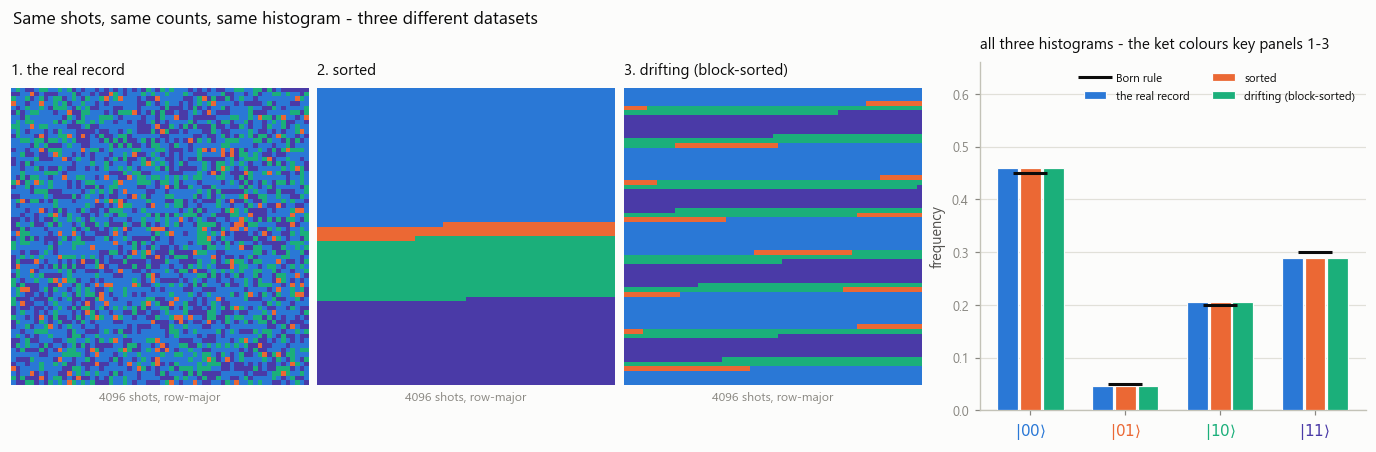

                     variant                     counts    runs
          1. the real record      [1883  186  843 1184]    2721
                   2. sorted      [1883  186  843 1184]       4
  3. drifting (block-sorted)      [1883  186  843 1184]      25
   expected for i.i.d. shots                               2724


In [7]:
# The 4096 shots from Part 1, as integers 0..3 in the order they were produced.
ints = np.array([int(b, 2) for b in res_aer[0].data.c.get_bitstrings()])
SIDE = 64
assert ints.size == SIDE * SIDE == SHOTS

order_sorted = np.sort(ints)
BLOCK = 512
# Sort within blocks, alternating direction, so the result reads as a slow
# wander rather than one staircase.
order_drift = np.concatenate([
    np.sort(ints[i:i + BLOCK])[:: 1 if (i // BLOCK) % 2 == 0 else -1]
    for i in range(0, SHOTS, BLOCK)])

variants = [("1. the real record", ints),
            ("2. sorted", order_sorted),
            ("3. drifting (block-sorted)", order_drift)]

OUT_CMAP = ListedColormap([style.BLUE, style.ORANGE, style.AQUA, style.VIOLET])

fig = plt.figure(figsize=(12.4, 4.0))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.3])
for k, (name, v) in enumerate(variants):
    ax = fig.add_subplot(gs[0, k])
    ax.imshow(v.reshape(SIDE, SIDE), cmap=OUT_CMAP, vmin=-0.5, vmax=3.5,
              interpolation="nearest", aspect="equal")
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(name, loc="left", fontsize=10)
    ax.set_xlabel(f"{SHOTS} shots, row-major", fontsize=8, color=style.MUTED)

axh = fig.add_subplot(gs[0, 3])
for (name, v), off, col in zip(variants, (-0.24, 0.0, 0.24),
                               (style.BLUE, style.ORANGE, style.AQUA)):
    f = np.bincount(v, minlength=4) / SHOTS
    axh.bar(np.arange(4) + off, f, width=0.22, color=col, zorder=3,
            edgecolor=style.SURFACE, linewidth=0.8, label=name.split(". ")[1])
axh.plot(np.arange(4), p_exact, ls="none", marker="_", ms=22, mew=2.0,
         color=style.INK, zorder=5, label="Born rule")
axh.set_xticks(range(4))
axh.set_xticklabels([grid.ket(s) for s in LABELS], fontsize=10)
# The tick labels ARE the colour key for panels 1-3: each ket is drawn in the
# colour that outcome takes in the bitmaps, so no separate legend is needed.
for k, lab in enumerate(axh.get_xticklabels()):
    lab.set_color(OUT_CMAP.colors[k])
    lab.set_fontweight("medium")
axh.set_ylim(0, 0.66)
axh.set_ylabel("frequency")
axh.set_title("all three histograms - the ket colours key panels 1-3",
              loc="left", fontsize=10)
axh.legend(fontsize=7.5, ncols=2, loc="upper right")
axh.set_axisbelow(True)

fig.suptitle("Same shots, same counts, same histogram - three different datasets",
             x=0.005, ha="left", fontsize=11.5)
plt.show()


def runs(v):
    """Number of maximal constant runs - a crude serial-dependence statistic."""
    return 1 + int(np.sum(v[1:] != v[:-1]))


expected_runs = 1 + (SHOTS - 1) * (1 - float((p_exact ** 2).sum()))
print(f"{'variant':>28} {'counts':>26} {'runs':>7}")
for name, v in variants:
    print(f"{name:>28} {str(np.bincount(v, minlength=4)):>26} {runs(v):7d}")
print(f"{'expected for i.i.d. shots':>28} {'':>26} {expected_runs:7.0f}")

The `counts` column is character-for-character identical across all three rows,
because permuting a list cannot change how many of each thing is in it. The
`runs` column separates them instantly, and the real record sits right on the
i.i.d. expectation.

That is the honest summary of the whole section: **`get_counts()` is the right
tool once you have established independence, and it is structurally incapable of
establishing it.** A run test, a lag-1 autocorrelation, or simply looking at the
bitmap costs nothing and is the only reason you get to believe the error bar.

---

## Part 4 — `get_counts()` vs `get_bitstrings()` vs the raw `BitArray`

Three ways out of one object, in decreasing order of how much they discard.

| call | returns | keeps shot order? | cost |
|---|---|---|---|
| `.get_counts()` | `dict[str, int]` | no | O(shots), tiny result |
| `.get_int_counts()` | `dict[int, int]` | no | same, handy for indexing |
| `.get_bitstrings()` | `list[str]`, length = shots | **yes** | one Python string per shot |
| `.array` | `uint8`, shape `(shots, ceil(bits/8))` | **yes** | the actual stored bytes |
| `.to_bool_array()` | `bool`, shape `(shots, bits)` | **yes** | the analysis-friendly form |

`.array` is the storage format and it is **bit-packed**: 12 measured qubits are
stored in 2 bytes per shot, not 12. That is why its second axis is 2 and not 12,
and why you should reach for `to_bool_array()` rather than unpacking it
yourself.

`BitArray` also carries a few operations that are much cheaper than
reconstructing the record by hand — `slice_bits` to pull out particular clbits,
`postselect` to keep only the shots matching a pattern (which is how syndrome
post-selection and teleportation verification are actually done, in C27 and
B25), and `expectation_values` for Pauli-Z observables.

In [8]:
ba = rec_bits           # the 12-qubit, 420-shot record from Part 3

print("num_shots :", ba.num_shots, "   num_bits:", ba.num_bits)
print("array     :", ba.array.shape, ba.array.dtype,
      "<- BIT-PACKED: 12 bits in", ba.array.shape[1], "bytes")
print("to_bool   :", ba.to_bool_array().shape, ba.to_bool_array().dtype)
print()

c12 = ba.get_counts()
print("get_counts()      :", len(c12), "distinct bitstrings out of 2^12 = 4096")
print("  the 3 commonest :", sorted(c12.items(), key=lambda kv: -kv[1])[:3])
print("get_bitstrings()  : list of", len(ba.get_bitstrings()), "strings;",
      "first =", ba.get_bitstrings()[0])
print("get_int_counts()  : same tally keyed by int, e.g.",
      sorted(ba.get_int_counts().items(), key=lambda kv: -kv[1])[:2])
print()

# slice_bits: keep only the correlated Bell pair (clbits 3 and 4).
pair = ba.slice_bits([3, 4])
print("slice_bits([3, 4]) ->", pair.get_counts(),
      "   <- only 00 and 11 survive: the pair is perfectly correlated")

# postselect: keep the shots where q2 came out 1 (it always does) and q1 came
# out 0 (it always does). Nothing should be discarded.
kept = ba.postselect([1, 2], [False, True])
print("postselect(q1=0, q2=1) ->", kept.num_shots, "of", ba.num_shots, "shots kept")

# A BitArray can also be built from scratch, which is how you round-trip a
# record you saved to disk or generated yourself.
made = BitArray.from_samples(["101", "010", "101"], num_bits=3)
print("\nBitArray.from_samples(...) ->", made.get_counts())

num_shots : 420    num_bits: 12
array     : (420, 2) uint8 <- BIT-PACKED: 12 bits in 2 bytes
to_bool   : (420, 12) bool

get_counts()      : 148 distinct bitstrings out of 2^12 = 4096
  the 3 commonest : [('111100111101', 9), ('101100111100', 8), ('110100100101', 8)]
get_bitstrings()  : list of 420 strings; first = 000101000101
get_int_counts()  : same tally keyed by int, e.g. [(3901, 9), (2876, 8)]

slice_bits([3, 4]) -> {'00': 214, '11': 206}    <- only 00 and 11 survive: the pair is perfectly correlated
postselect(q1=0, q2=1) -> 420 of 420 shots kept

BitArray.from_samples(...) -> {'101': 2, '010': 1}


### PUB broadcasting: one job, a whole parameter sweep

The `parameter_values` slot is the reason PUBs are shaped the way they are. Bind
an array of values and the result's `BitArray` grows a leading axis — one
sub-record per binding, all from a single `run()` call. On hardware that is the
difference between one queue wait and twenty.

one PUB in, one result out: BitArray  shape (25,)  shots each 2048


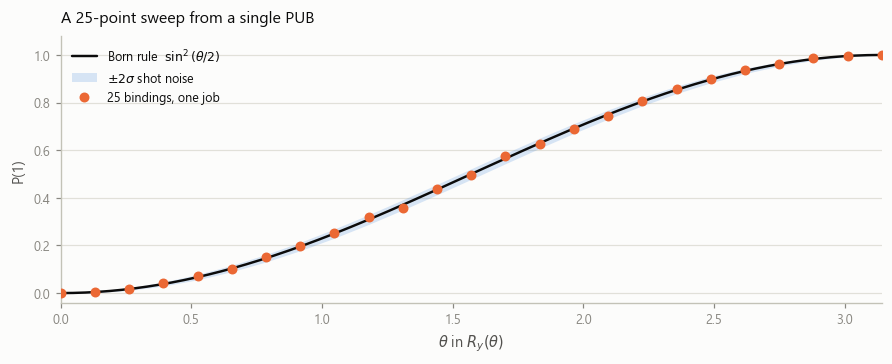

max |measured - analytic| = 0.0132    worst 2-sigma band = 0.0221


In [9]:
from qiskit.circuit import Parameter

t = Parameter("theta")
qs, cs = QuantumRegister(1, "q"), ClassicalRegister(1, "c")
sweep = QuantumCircuit(qs, cs)
sweep.ry(t, 0)
sweep.measure(qs, cs)

ANGLES = np.linspace(0, np.pi, 25)
SWEEP_SHOTS = 2048
sweep_isa = transpile(sweep, AER, optimization_level=1, seed_transpiler=SEED)

# ONE pub, ONE job: parameter_values has shape (25, 1).
sweep_res = (backends.sampler(shots=SWEEP_SHOTS, seed=SEED)
             .run([(sweep_isa, ANGLES.reshape(-1, 1))]).result())
sweep_ba = sweep_res[0].data.c
print("one PUB in, one result out:", type(sweep_ba).__name__,
      " shape", sweep_ba.shape, " shots each", sweep_ba.num_shots)

# .shape is the parameter-sweep shape; get_counts(i) tallies one binding's
# sub-record, and sweep_ba[i] hands back that sub-record as its own BitArray.
measured = np.array([sweep_ba.get_counts(i).get("1", 0) / SWEEP_SHOTS
                     for i in range(len(ANGLES))])
analytic = np.sin(ANGLES / 2) ** 2
err = np.sqrt(np.clip(analytic * (1 - analytic), 0, None) / SWEEP_SHOTS)

fig, ax = plt.subplots(figsize=(8.0, 3.2))
fine = np.linspace(0, np.pi, 400)
ax.plot(fine, np.sin(fine / 2) ** 2, color=style.INK, lw=1.6, zorder=3,
        label=r"Born rule  $\sin^2(\theta/2)$")
ax.fill_between(ANGLES, analytic - 2 * err, analytic + 2 * err,
                color=style.BLUE, alpha=0.18, lw=0, zorder=2,
                label=r"$\pm 2\sigma$ shot noise")
ax.plot(ANGLES, measured, ls="none", marker="o", ms=5.5, color=style.ORANGE,
        zorder=4, label=f"{len(ANGLES)} bindings, one job")
ax.set_xlabel(r"$\theta$ in $R_y(\theta)$")
ax.set_ylabel("P(1)")
ax.set_xlim(0, np.pi)
ax.set_ylim(-0.04, 1.08)
ax.set_title("A 25-point sweep from a single PUB", loc="left", fontsize=10.5)
ax.legend(fontsize=8.2, loc="upper left")
plt.show()

print("max |measured - analytic| =", round(float(np.abs(measured - analytic).max()), 4),
      "   worst 2-sigma band =", round(float(2 * err.max()), 4))

---

## Part 5 — how many shots? (the honest limit)

Everything above assumed the shots were free. They are not, and the cost model
is the least forgiving thing in quantum computing.

Each shot is an independent Bernoulli trial, so the estimator $\hat p = k/N$ has

$$\operatorname{Var}[\hat p] = \frac{p(1-p)}{N}, \qquad
\sigma[\hat p] = \sqrt{\frac{p(1-p)}{N}} \;\le\; \frac{1}{2\sqrt N}.$$

Unbiased, and converging as $N^{-1/2}$. A04 derived this and drew it from a
NumPy sampler; here is the same picture drawn from **Aer's SamplerV2**, because
the whole point is that the SDK does not change it.

Fifty independent runs out to 8192 shots on a state with $P(0) = 0.7$, each
translucent line one run's running estimate, bands drawn from the formula rather
than fitted.

**What a 1% effect costs.** To resolve a difference of $\varepsilon = 0.01$ you
need $\sigma \lesssim \varepsilon$, so $N \gtrsim 0.25/\varepsilon^2 =
2.5 \times 10^{3}$ shots for a one-sigma wobble — and if you actually want to
*claim* the effect, five sigma on a comparison of two independently measured
probabilities needs

$$N \;\gtrsim\; \frac{2 \cdot 5^2 \, p(1-p)}{\varepsilon^2} \;\approx\;
1.3 \times 10^{5} \text{ shots per side}.$$

So "about $10^4$ shots for a 1% effect" is the optimistic reading and $10^5$ is
the one you should budget. That is per circuit, per parameter point. A modest
16-point sweep at that precision is millions of shots, which on real hardware is
job submissions, queue time and a real bill — and it is why the answer is
usually to redesign the circuit so the signal is 30% rather than 1%.

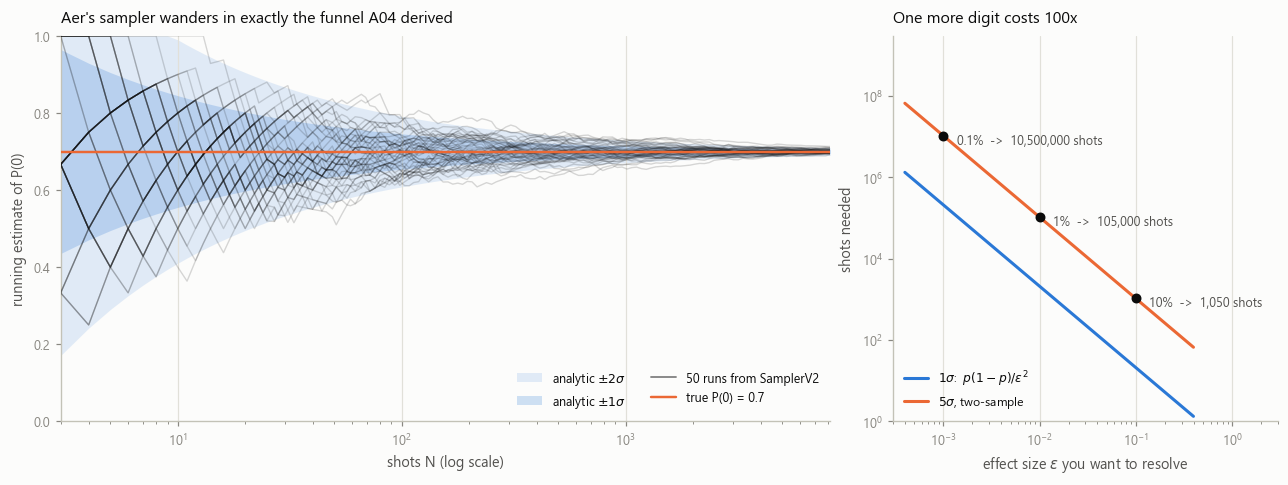

N =    16   sigma = 0.1146   runs within 1 sigma: 82%  (expected ~68%)
N =   252   sigma = 0.0289   runs within 1 sigma: 60%  (expected ~68%)
N =  4082   sigma = 0.0072   runs within 1 sigma: 62%  (expected ~68%)

shots for a 1% effect at 5 sigma, two-sample: 105,000 per side


In [10]:
P_TRUE = 0.7
N_MAX, RUNS = 8192, 50

qf, cf = QuantumRegister(1, "q"), ClassicalRegister(1, "c")
fan = QuantumCircuit(qf, cf)
fan.ry(theta(1 - P_TRUE), 0)          # P(1) = 0.3, so P(0) = 0.7
fan.measure(qf, cf)
fan_isa = transpile(fan, AER, optimization_level=1, seed_transpiler=SEED)

# RUNS * N_MAX shots in one job, then reshaped into RUNS independent runs.
fan_ba = (backends.sampler(shots=RUNS * N_MAX, seed=SEED)
          .run([fan_isa]).result()[0].data.c)
bits = fan_ba.to_bool_array(order="little")[:, 0].reshape(RUNS, N_MAX)
hit_zero = (~bits).astype(float)          # outcome 0 means the bit is False
running = np.cumsum(hit_zero, axis=1) / np.arange(1, N_MAX + 1)

# Log-spaced sample points: 50 x 8192 vertices is 400k points for no extra
# information, and the notebook has a size budget.
ticks = np.unique(np.round(np.logspace(np.log10(3), np.log10(N_MAX),
                                       160)).astype(int))
curves = running[:, ticks - 1]
sigma = np.sqrt(P_TRUE * (1 - P_TRUE) / ticks)

fig = plt.figure(figsize=(11.6, 4.3))
gs = fig.add_gridspec(1, 3)
axf = fig.add_subplot(gs[0, :2])
axn = fig.add_subplot(gs[0, 2])

axf.fill_between(ticks, np.clip(P_TRUE - 2 * sigma, 0, 1),
                 np.clip(P_TRUE + 2 * sigma, 0, 1),
                 color=style.BLUE, alpha=0.13, lw=0, zorder=1,
                 label=r"analytic $\pm 2\sigma$")
axf.fill_between(ticks, np.clip(P_TRUE - sigma, 0, 1),
                 np.clip(P_TRUE + sigma, 0, 1),
                 color=style.BLUE, alpha=0.22, lw=0, zorder=2,
                 label=r"analytic $\pm 1\sigma$")
for row in curves:
    axf.plot(ticks, row, color=style.INK, alpha=0.16, lw=0.9, zorder=3)
axf.plot([], [], color=style.INK, alpha=0.5, lw=1.2,
         label="50 runs from SamplerV2")
axf.axhline(P_TRUE, color=style.ORANGE, lw=1.6, zorder=4,
            label=f"true P(0) = {P_TRUE}")
axf.set_xscale("log")
axf.set_xlim(3, N_MAX)
axf.set_ylim(0, 1)
axf.set_xlabel("shots N (log scale)")
axf.set_ylabel("running estimate of P(0)")
axf.set_title("Aer's sampler wanders in exactly the funnel A04 derived",
              loc="left", fontsize=10.5)
axf.legend(loc="lower right", fontsize=8.2, ncols=2)
axf.grid(axis="both")

eps = np.logspace(-3.4, -0.4, 240)
pq = P_TRUE * (1 - P_TRUE)
axn.plot(eps, pq / eps ** 2, color=style.BLUE, lw=2.0, zorder=3,
         label=r"$1\sigma$:  $p(1-p)/\varepsilon^2$")
axn.plot(eps, 2 * 25 * pq / eps ** 2, color=style.ORANGE, lw=2.0, zorder=3,
         label=r"$5\sigma$, two-sample")
for e, lab in ((0.1, "10%"), (0.01, "1%"), (0.001, "0.1%")):
    n5 = 2 * 25 * pq / e ** 2
    axn.plot([e], [n5], marker="o", ms=5.5, color=style.INK, zorder=5)
    axn.annotate(f"{lab}  ->  {n5:,.0f} shots", (e, n5),
                 textcoords="offset points", xytext=(9, -3), fontsize=8.2,
                 color=style.INK_2, ha="left", va="center")
axn.set_xscale("log")
axn.set_yscale("log")
axn.set_xlim(3e-4, 3.0)
axn.set_ylim(1, 3e9)
axn.set_xlabel(r"effect size $\varepsilon$ you want to resolve")
axn.set_ylabel("shots needed")
axn.set_title("One more digit costs 100x", loc="left", fontsize=10.5)
axn.legend(fontsize=8, loc="lower left")
axn.grid(axis="both")

plt.show()

for N in (16, 256, 4096):
    j = int(np.argmin(np.abs(ticks - N)))
    inside = np.mean(np.abs(curves[:, j] - P_TRUE) <= sigma[j])
    print(f"N = {ticks[j]:5d}   sigma = {sigma[j]:.4f}   "
          f"runs within 1 sigma: {inside*100:.0f}%  (expected ~68%)")
print("\nshots for a 1% effect at 5 sigma, two-sample:",
      f"{2 * 25 * pq / 0.01 ** 2:,.0f} per side")

---

## Honest limits

**The bitmap does not scale either.** 420 shots x 12 qubits is 5040 pixels and
reads beautifully. A realistic job is $10^5$ shots on 100 qubits — ten million
pixels, which is a screen-sized image of noise. Past a few thousand shots the
bitmap stops being a picture you read and becomes a picture you *scan for
structure*, which is still worth doing once, and is not a substitute for a run
test or an autocorrelation.

**Everything here is noiseless.** Aer's `SamplerV2` sampled from an ideal state.
Real readout misassigns 0 for 1 at the percent level, and that is a **bias**, not
shot noise: it does not shrink as $1/\sqrt N$. Past roughly $10^4$ shots you stop
measuring your state and start measuring your readout error, which is precisely
the regime the Part 5 figure says you need for a 1% effect. B26 and C27 take that
apart.

**`StatevectorSampler` is not simulating shots.** It computes the exact
amplitudes and then draws from the resulting multinomial. It is a perfect
sampler from a perfect state, so it can never show you a correlated record —
which makes it the wrong tool for exactly the question Part 3 asks. Aer's
shot-by-shot simulation is closer, but it is still i.i.d. by construction. Only
hardware produces genuinely correlated shot records, and this notebook cannot
show you one.

**A seeded sampler is not random.** Every number in this notebook is
reproducible, which is what makes the repo reviewable and is also a small lie:
the whole subject is irreducible randomness, and we have pinned it. Change
`SEED` and every bitmap here changes while every conclusion does not.

**Counts hide the shot order; shot order hides the state.** The record is the
most raw thing a quantum computer will give you, and it is still a projection.
It has already thrown away the amplitudes, the phases, and the entire
superposition — A04's Part 2 is where that irreversibility gets its own picture.
Two very different states can produce identical shot records in the $Z$ basis;
that is why B19 has to *change the measurement basis* to see anything.

## Checkpoint

Track B closes by asserting against the Track A result it mirrors. Here that is
A04: its inverse-CDF sampler, re-implemented inline with a seeded NumPy RNG,
against Qiskit's primitives on the same state.

**Choosing the tolerance from the statistics, not from what passes.** Two
*independent* estimates of the same probability $p$ from $N$ shots each have a
difference with standard deviation $\sqrt{2p(1-p)/N} \le 1/\sqrt{2N}$. With
$N = 200{,}000$ that bound is $1.58\times10^{-3}$, so a 5-sigma threshold is
$7.9\times10^{-3}$. That number is written below as a formula, not a constant,
and it was not adjusted after seeing the result.

In [11]:
# ---- the A04 sampler, re-implemented here (Track A never imports Qiskit) ----
def probabilities(state):
    """Born rule: P(k) = |amplitude_k|^2."""
    p = np.abs(np.asarray(state)) ** 2
    return p / p.sum()


def measure_shots(state, shots, rng):
    """A04's inverse-CDF sampler, verbatim in spirit: no library sampler."""
    cdf = np.cumsum(probabilities(state))
    cdf[-1] = 1.0
    return np.searchsorted(cdf, rng.random(shots), side="right")


N_CHECK = 200_000
check_rng = np.random.default_rng(SEED + 1)

track_a = np.bincount(measure_shots(PSI, N_CHECK, check_rng), minlength=4) / N_CHECK
track_b = freqs(backends.sampler(shots=N_CHECK, seed=SEED + 1)
                .run([qc_isa]).result()[0].data.c)

# Tolerance derived, not tuned: sd of a difference of two independent estimates
# is sqrt(2 p (1-p) / N) <= 1/sqrt(2N); take 5 sigma of the worst case.
TOL = 5 * np.sqrt(0.5 / N_CHECK)

print(f"{'outcome':>8} {'Born rule':>11} {'Track A (NumPy)':>17} "
      f"{'Track B (Aer)':>15} {'|A - B|':>10}")
for i, lab in enumerate(LABELS):
    print(f"{lab:>8} {p_exact[i]:11.5f} {track_a[i]:17.5f} "
          f"{track_b[i]:15.5f} {abs(track_a[i]-track_b[i]):10.5f}")
print(f"\ntolerance = 5 * sqrt(0.5 / {N_CHECK}) = {TOL:.6f}")

# 1. THE cross-track assertion: A04's hand-rolled sampler and SamplerV2 agree.
assert np.max(np.abs(track_a - track_b)) < TOL, np.max(np.abs(track_a - track_b))

# 2. ...and both agree with the analytic Born rule, one-sample this time.
assert np.max(np.abs(track_a - p_exact)) < 5 * np.sqrt(0.25 / N_CHECK)
assert np.max(np.abs(track_b - p_exact)) < 5 * np.sqrt(0.25 / N_CHECK)

# 3. The circuit really prepares |psi> (StatePreparation + transpile preserved it).
assert np.allclose(Statevector(qc.remove_final_measurements(inplace=False)).data,
                   PSI, atol=1e-10)

# 4. Register-name contract: "c" everywhere in this repo, "meas" from measure_all.
assert list(res_aer[0].data.keys()) == ["c"]
assert list(r_all[0].data.keys()) == ["meas"]

# 5. BitArray round-trip: bitstrings, bool array and counts are the same record.
bs = rec_bits.get_bitstrings()
assert len(bs) == N_ROWS and BITS.shape == (N_ROWS, N_Q)
# order="little" puts clbit j in column j, i.e. the REVERSED bitstring.
assert all(s[::-1] == "".join("1" if b else "0" for b in row)
           for s, row in zip(bs[:64], BITS[:64]))
assert sum(rec_bits.get_counts().values()) == N_ROWS

# 6. The shot record says what the circuit said it would.
assert BITS[:, 1].sum() == 0                   # q1 never fires
assert BITS[:, 2].all()                        # q2 always fires
assert np.array_equal(BITS[:, 3], BITS[:, 4])  # Bell pair: identical columns
assert np.array_equal(BITS[:, 5], ~BITS[:, 6])  # Bell pair + X: complementary

# 7. Permutation invariance of counts - the Part 3 punchline, as an assertion.
for _, v in variants:
    assert np.array_equal(np.bincount(v, minlength=4),
                          np.bincount(ints, minlength=4))
assert runs(order_sorted) < runs(ints) / 100     # yet the records differ wildly

# 8. The PUB sweep tracks sin^2(theta/2) within its own error bars.
assert np.max(np.abs(measured - analytic)) < 5 * np.sqrt(0.25 / SWEEP_SHOTS)

# 9. Phase is invisible to measurement (A04's point, now through the SDK).
assert np.allclose(probabilities(PSI * np.exp(1j * 1.234)), probabilities(PSI))

# 10. Shot noise really is 1/sqrt(N): the fan's spread halves per 4x in N.
spread = [float(np.std(curves[:, int(np.argmin(np.abs(ticks - N)))]))
          for N in (128, 512, 2048)]
assert 1.6 < spread[0] / spread[1] < 2.5 and 1.6 < spread[1] / spread[2] < 2.5

print("\nB16 checkpoint passed.")

 outcome   Born rule   Track A (NumPy)   Track B (Aer)    |A - B|
      00     0.45000           0.45177         0.45062    0.00115
      01     0.05000           0.04989         0.04987    0.00002
      10     0.20000           0.19950         0.20026    0.00076
      11     0.30000           0.29884         0.29924    0.00041

tolerance = 5 * sqrt(0.5 / 200000) = 0.007906

B16 checkpoint passed.


---

**Next:** [B17 — Multi-Qubit Circuits and Ordering](B17_Multi_Qubit_Ordering.ipynb).
We have been quietly relying on `order="little"` to put qubit `j` in column `j`
of the bitmap, and on `"10"` meaning `c[1]=1, c[0]=0`. B17 is where that
convention gets pulled out and stress-tested — including the version where you
get it wrong, the code runs, and the answer is a different one.